# Digit recognizer
Programa creado para clasificar imágenes 28x28 de dígitos según su etiqueta 0-9 con algoritmos de Inteligencia Artificial

# Análisis del dataset

In [ ]:
import pandas as pd

raw_train = pd.read_csv("train.csv")
raw_test = pd.read_csv("test.csv")

In [ ]:
pixels = raw_train.drop("label", axis = 1) #elimino la columna "label" del dataframe

In [ ]:
raw_train.describe()
raw_test.describe()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,28000.0,28000.0,28000.0,28000.0,28000.0,28000.0,28000.0,28000.0,28000.0,28000.0,...,28000.000000,28000.000000,28000.000000,28000.000000,28000.000000,28000.0,28000.0,28000.0,28000.0,28000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.164607,0.073214,0.028036,0.011250,0.006536,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.473293,3.616811,1.813602,1.205211,0.807475,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,253.000000,254.000000,193.000000,187.000000,119.000000,0.0,0.0,0.0,0.0,0.0


In [ ]:
pixels.describe()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [ ]:
raw_train.info()
raw_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 786 entries, label to pixel 784 f
dtypes: float64(1), int64(785)
memory usage: 251.9 MB
<class 'pandas.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Columns: 784 entries, pixel0 to pixel783
dtypes: int64(784)
memory usage: 167.5 MB


Gestión de valores nulos

In [ ]:
train_nulls = raw_train.isnull().sum().values
test_nulls = raw_test.isnull().sum().values

print(f"Número de valores nulos en train: {train_nulls.sum()}")
print(f"Número de valores nulos en test: {test_nulls.sum()}")

Número de valores nulos en train: 0
Número de valores nulos en test: 0


Vemos en la documentación (https://www.kaggle.com/competitions/digit-recognizer) que las imágenes tienen 28x28 píxeles en escala de grises, con valores entre 0-255

Vamos a crear una función que muestre por pantalla una imagen específica del dataset para visualizarla mejor

In [ ]:
# Como parece que vamos a usar mucho este código, añado una función que convierta una fila de los datos en un array 2D
def crearMatriz(df, raw): #Parámetros: 1) Dataframe (matriz en 2D, filas y columnas) 2) un valor i
    img = df.iloc[raw]                            #Variable Imagen = la fila i completa (784 valores seguidos en línea del 28x28)

    label = img.iloc[0]                         #label es el valor de la columna 1 del Series (no DataFrame)
    title = f"Image #{raw} (Number {label})"      
    img = img.values[1:]                        #Pasas el dataframe de pandas a un numpy array sin la columna de los labels

    img = img.reshape((28, 28))                 # Ahora, transformamos el array en un array 2D, 28x28
    
    return img, label, title

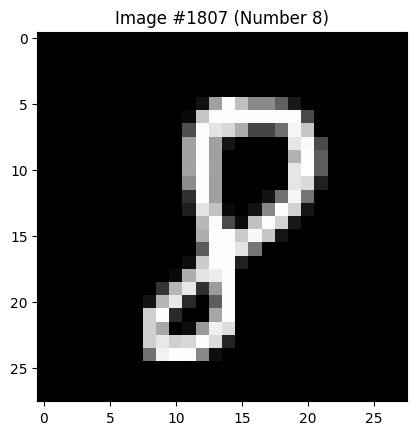

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def mostrarImagen(df, raw):
    """
    df: dataframe | list
    i: integer
    """
    if isinstance (df,list): #cambio a isinstance para mayor flexibilidad en el caso de que haya herencia o algo así rarete
        # La imagen que buscamos es un elemento de esa lista
        img = df[raw]
        title = f"Número {raw}"
    else:
        img, label, title = crearMatriz(df, raw)

    plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    plt.title(label=title)
    plt.show()

mostrarImagen(raw_train, 1807)

Creamos una función para visualizar todos los datos de un dataset [simplemente para probar que números aparecen]

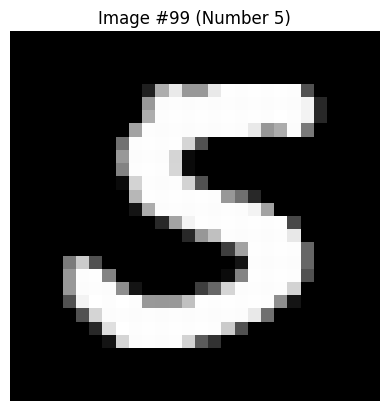

In [ ]:
from IPython.display import clear_output


def mostrarImgsDataframe(df, inicio, fin):
    # Activa modo interactivo
    plt.ion()

    for i in range(inicio, fin):
        # Usamos el código anterior para dibujar la matriz 2D
        img, label, title = crearMatriz(df, i)

        plt.imshow(img, cmap="gray", vmin=0, vmax=255)
        plt.title(label=title)
        plt.axis("off")

        # Refrescamos la ventana y esperamos N segundos
        plt.pause(0.02)

        # Borramos el output anterior
        clear_output(wait=True)
        plt.show()


mostrarImgsDataframe(raw_train, 0, 100)

# Creación de las matrices de 'números ideales'

Con el fin de evaluar a que label corresponde cada matriz, vamos a comprobar a que 'número ideal' se parece más dicha matriz. Estos 'números ideales' serán calculados como la media de los números de ese 'label'; es decir, se superponen los números uno encima de otro y se calcula cual es el 'número promedio' o 'número ideal'

In [ ]:
print(len(raw_train))

42000


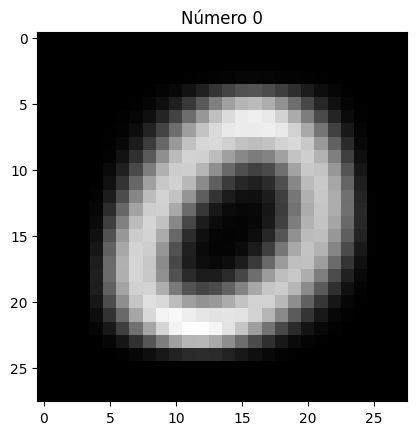

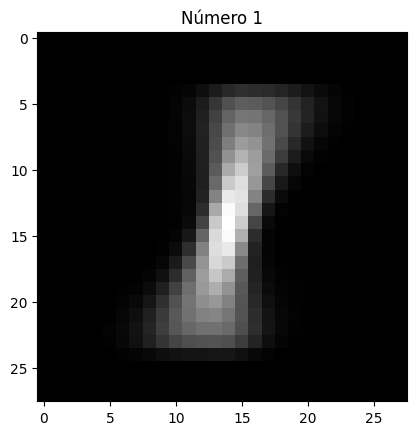

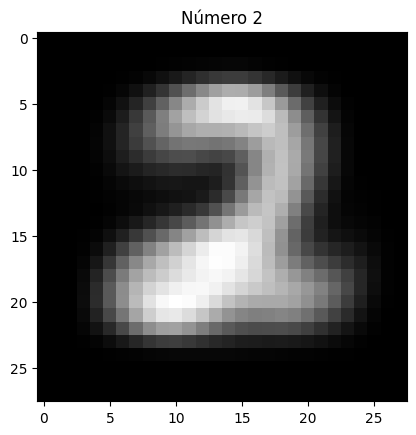

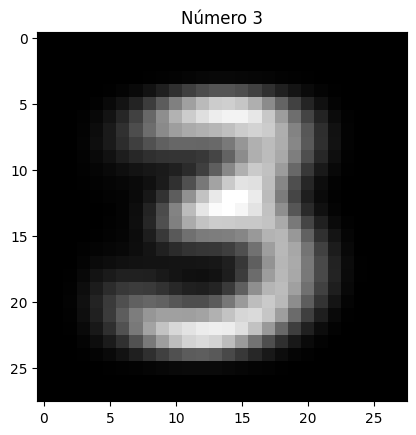

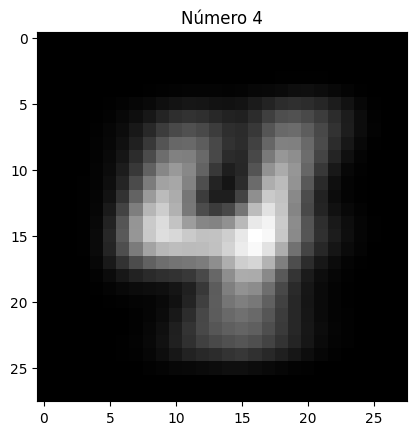

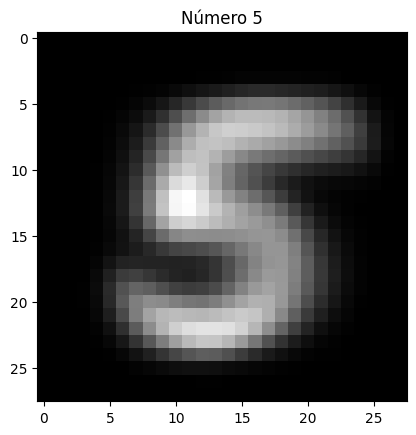

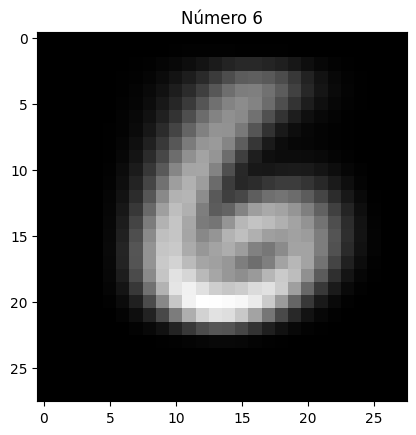

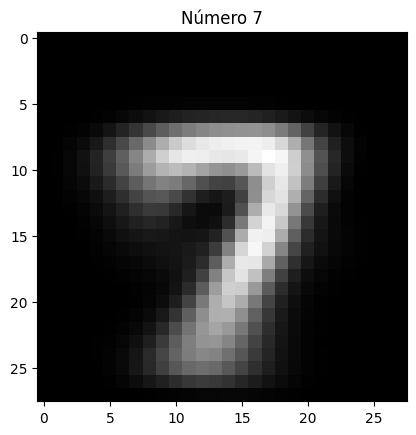

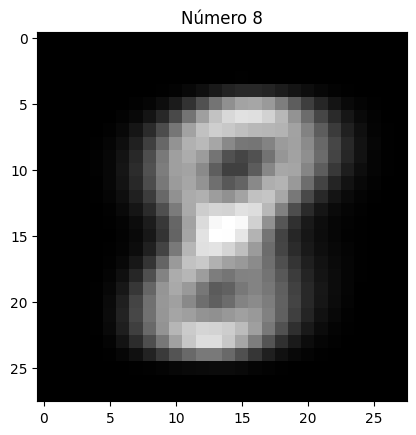

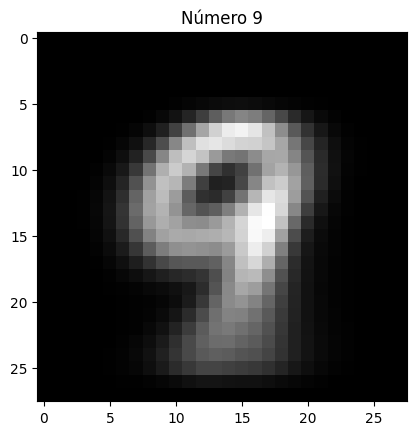

In [ ]:
# Para el conjunto 'train', se crea un número ideal para cada label 0-9
# Creamos unas matrices para guardar la suma/superposición de matrices
nums_ideales = []
for i in range(10):                         # se repite 10 veces
    matriz = np.zeros((28, 28))             #creas una matriz 28x28 llena de ceros 
    nums_ideales.append(matriz)             #En la lista num_ideales guardas 10 matrices 28x28 con ceros

for i in range(len(raw_train)):                 # se repite 42.000 veces (se repite para todos los datos del trainset)
    img, label, _ = crearMatriz(raw_train, i)   # guardas en img la imagen de cada dígito de la fila i y guardas en label el dígito que es
    
    # Sumamos los valores de cada pixel a su matriz correspondiente
    nums_ideales[label] += img                  #sumas a la matriz asociada a cada dígito el valor de la imagen 

# Ahora, necesitamos normalizar los valores entre 0 y 255
for i in range(len(nums_ideales)):
    valor_maximo = nums_ideales[i].max()
    if valor_maximo == 0:
        raise ValueError("La matriz está vacía")

    # El valor máximo tendrá un valor de (255 / valor_maximo) * valor_minimo = 255
    # Y el mínimo (255 / valor_maximo) * 0 = 0
    nums_ideales[i] = np.multiply(255 / valor_maximo, nums_ideales[i])

# Podemos visualizar el resultado usando las funciones anteriores
for i in range(10):
    mostrarImagen(nums_ideales, i)

# Clasificador


Ahora con las 10 matrices de números ideales, se clasificarán los dígitos en función de a qué matriz ideal se parece más

SGD Clasificador provisional, no tengo ni idea de cómo va, solo sé que sirve para calsificar y que va bien

In [ ]:
def dominio_imagen (df, label_target):
    X = df.drop(label_target, axis=1)
    Y = df[label_target]
    return X, Y

In [ ]:
raw_test_copia = raw_test.copy()

raw_test_copia.insert(0, "label", np.zeros(28000))

ValueError: cannot insert label, already exists

In [ ]:
X_train, y_train = dominio_imagen(raw_train, "label")
x_test, y_test = dominio_imagen(raw_test, "label")

y_train_5 = (y_train ==5)
y_test_5 = (y_test == 5)

In [ ]:
from sklearn.linear_model import SGDClassifier

SGD_clf = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
SGD_clf.fit(X_train, y_train_5)


,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [ ]:
#una predicción random
import random

linea_random = random.randint(0, 28000)
SGD_clf.predict(X_train.iloc[[linea_random]])

array([False])

# EVALUADOR

Vamos a desarrollar diferentes formas de evaluar el desempeño de un clasficador y luego elegir cuál es la mejor

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))